# Ecommerce Funnel Drop-Off Analysis

This notebook analyzes ordered GA4 ecommerce funnel progression for December 2020 and visualizes where users drop off between product view, cart, checkout, shipping, payment, and purchase steps.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from google.cloud import bigquery

PROJECT_ID = "ga4-ecommerce-portfolio-504020"
client = bigquery.Client(project=PROJECT_ID)

In [2]:
# funnel query
possible_paths = [
    Path("sql/04_ordered_session_funnel_counts_conversion.sql"),
    Path("../sql/04_ordered_session_funnel_counts_conversion.sql"),
]
funnel_sql_path = next(path for path in possible_paths if path.exists())
funnel_query = funnel_sql_path.read_text()
funnel_df = client.query(funnel_query).to_dataframe()
funnel_df

/Users/nikkifackler/Library/CloudStorage/OneDrive-UniversityofNorthCarolinaatChapelHill/Fackler/Git Repos/GA4-Ecommerce-Funnel-Analytics-ML/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,view_item,add_to_cart,begin_checkout,add_shipping_info,add_payment_info,purchase,add_to_cart_conv_rate,begin_checkout_conv_rate,add_shipping_conv_rate,add_payment_conv_rate,purchase_conv_rate,view_to_purchase_conv_rate
0,27971,8427,2945,659,398,278,0.3013,0.3495,0.2238,0.6039,0.6985,0.0099


In [3]:
# calculate dropoff counts and rates

funnel_steps = [
    "view_item",
    "add_to_cart",
    "begin_checkout",
    "add_shipping_info",
    "add_payment_info",
    "purchase",
]

step_labels = [
    "View item",
    "Add to cart",
    "Begin checkout",
    "Add shipping",
    "Add payment",
    "Purchase",
]

funnel_counts = funnel_df[funnel_steps].iloc[0]

dropoff_df = pd.DataFrame({
    "from_step": step_labels[:-1],
    "to_step": step_labels[1:],
    "from_count": funnel_counts.iloc[:-1].values,
    "to_count": funnel_counts.iloc[1:].values,
})

dropoff_df["dropoff_count"] = dropoff_df["from_count"] - dropoff_df["to_count"]
dropoff_df["dropoff_rate"] = dropoff_df["dropoff_count"] / dropoff_df["from_count"]

dropoff_df

,from_step,to_step,from_count,to_count,dropoff_count,dropoff_rate
0,View item,Add to cart,27971,8427,19544,0.698724
1,Add to cart,Begin checkout,8427,2945,5482,0.650528
2,Begin checkout,Add shipping,2945,659,2286,0.776231
3,Add shipping,Add payment,659,398,261,0.396055
4,Add payment,Purchase,398,278,120,0.301508


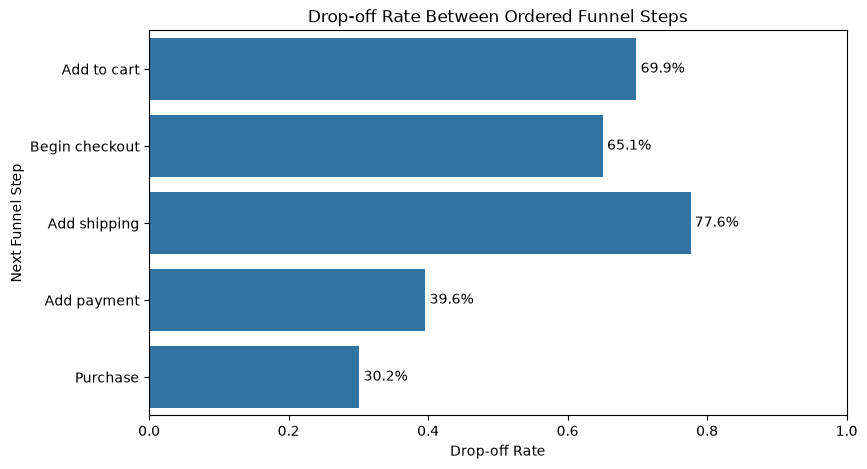

In [6]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=dropoff_df,
    x="dropoff_rate",
    y="to_step"
)

ax.bar_label(
    ax.containers[0],
    labels=[f"{x:.1%}" for x in dropoff_df["dropoff_rate"]],
    padding=3
)

plt.title("Drop-off Rate Between Ordered Funnel Steps")
plt.xlabel("Drop-off Rate")
plt.ylabel("Next Funnel Step")
plt.xlim(0, 1)
plt.savefig("../figures/ordered_funnel_dropoff.png", dpi=300, bbox_inches="tight")
plt.show()

The ordered funnel shows the largest drop-off before users reach the shipping-information step. Nearly 78% of sessions that began checkout did not continue to shipping information. There is also substantial drop-off earlier in the funnel, with about 70% of product-view sessions not reaching add-to-cart and 65% of add-to-cart sessions not reaching checkout.

Drop-off is lower in the final checkout steps, suggesting that users who reach payment are comparatively more likely to complete a purchase.